In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder

In [2]:
df = pd.read_csv('heart_disease_prediction_raw.csv')
df.sample(5)

,id,age,gender,chest_pain_type,resting_bp,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,oldpeak,slope,thal,heart_disease
32946,20304.0,90.0,F,NaN,126.0,524.000000,1.0,Normal,103.0,Yes,NaN,NaN,Normal,1.0
32425,28878.0,71.0,Male,Atypical Angina,184.0,1070.626481,1.0,Left Ventricular Hypertrophy,193.0,Yes,0.6,Upsloping,Fixed Defect,1.0
14485,53049.0,80.0,MALE,Non-Anginal Pain,132.0,337.000000,1.0,NaN,66.0,YES,4.5,upsloping,Fixed Defect,1.0
1164,NaN,84.0,Male,NaN,91.0,588.000000,1.0,Left Ventricular Hypertrophy,191.0,No,0.7,U,Normal,1.0
33887,20378.0,30.0,Male,Atypical Angina,102.0,178.000000,0.0,Left Ventricular Hypertrophy,188.0,N,0.6,Upsloping,Fixed Defect,0.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59289 entries, 0 to 59288
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   56381 non-null  float64
 1   age                  56384 non-null  float64
 2   gender               56325 non-null  object 
 3   chest_pain_type      56325 non-null  object 
 4   resting_bp           56376 non-null  float64
 5   cholesterol          56388 non-null  float64
 6   fasting_blood_sugar  56370 non-null  float64
 7   resting_ecg          56325 non-null  object 
 8   max_heart_rate       56388 non-null  float64
 9   exercise_angina      56325 non-null  object 
 10  oldpeak              56367 non-null  float64
 11  slope                56325 non-null  object 
 12  thal                 56325 non-null  object 
 13  heart_disease        56388 non-null  float64
dtypes: float64(8), object(6)
memory usage: 6.3+ MB


In [4]:
#Finding the number of duplicate rows in the dataset
df.duplicated().sum()

np.int64(158)

In [5]:
#removing duplicate rows
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [6]:
#Finding the number of missing values in each column
df.isnull().sum()

id                     2907
age                    2905
gender                 2964
chest_pain_type        2964
resting_bp             2913
cholesterol            2900
fasting_blood_sugar    2919
resting_ecg            2964
max_heart_rate         2901
exercise_angina        2964
oldpeak                2921
slope                  2964
thal                   2963
heart_disease          2901
dtype: int64

In [7]:
#dropping the 'id' column as it is not useful for analysis
df = df.drop(columns=['id'])

#drppping missing values in the 'heart_disease' column as it is the target variable and we cannot impute it
df = df.dropna(subset=['heart_disease'])
df.head()

,age,gender,chest_pain_type,resting_bp,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,oldpeak,slope,thal,heart_disease
0,19.0,MALE,Non-Anginal Pain,138.0,1070.626481,1.0,Left Ventricular Hypertrophy,192.0,No,6.4,Downsloping,Reversible Defect,1.0
1,68.0,MALE,Asymptomatic,164.0,279.000000,1.0,Normal,86.0,Yes,6.2,Downsloping,Normal,1.0
2,30.0,Female,ASYMPTOMATIC,141.0,234.000000,0.0,Normal,175.0,NO,3.9,Upsloping,Normal,0.0
3,24.0,Female,Atypical Angina,NaN,389.000000,1.0,Left Ventricular Hypertrophy,164.0,No,0.9,NaN,NaN,0.0
4,23.0,Female,Typical Angina,199.0,372.000000,NaN,Left Ventricular Hypertrophy,127.0,No,3.6,D,Reversible Defect,1.0


In [8]:
categorical_features = df.select_dtypes(include=['object']).columns
for col in categorical_features:
    print(f"Unique values in '{col}': {df[col].unique()}")

Unique values in 'gender': ['MALE' 'Female' 'Male' 'FEMALE' nan 'Female ' ' Male' 'M' 'Male ' 'F'
 'male' ' Female' 'female']
Unique values in 'chest_pain_type': ['Non-Anginal Pain' 'Asymptomatic' 'ASYMPTOMATIC' 'Atypical Angina'
 'Typical Angina' nan 'Asymptomatic ' 'typical angina' 'A' 'N'
 ' Asymptomatic' ' Typical Angina' 'ATYPICAL ANGINA' 'T'
 'NON-ANGINAL PAIN' 'Non-anginal pain' ' Non-Anginal Pain' 'asymptomatic'
 'Typical Angina ' 'Atypical angina' 'Non-Anginal Pain ' 'atypical angina'
 'Typical angina' 'TYPICAL ANGINA' 'Atypical Angina ' 'non-anginal pain'
 ' Atypical Angina']
Unique values in 'resting_ecg': ['Left Ventricular Hypertrophy' 'Normal' 'ST-T Wave Abnormality'
 'left ventricular hypertrophy' 'st-t wave abnormality' 'normal' nan
 'Left Ventricular Hypertrophy ' 'LEFT VENTRICULAR HYPERTROPHY'
 'ST-T Wave Abnormality ' 'L' 'NORMAL' ' ST-T Wave Abnormality' 'S'
 ' Left Ventricular Hypertrophy' 'St-t wave abnormality'
 'Left ventricular hypertrophy' 'ST-T WAVE ABNORMALI

In [9]:
for col in categorical_features:
    df[col] = df[col].str.strip().str.lower()
    df[col] = df[col].replace('nan', np.nan)

for col in categorical_features:
    print(f"Unique values in '{col}': {df[col].unique()}")



Unique values in 'gender': ['male' 'female' nan 'm' 'f']
Unique values in 'chest_pain_type': ['non-anginal pain' 'asymptomatic' 'atypical angina' 'typical angina' nan
 'a' 'n' 't']
Unique values in 'resting_ecg': ['left ventricular hypertrophy' 'normal' 'st-t wave abnormality' nan 'l'
 's' 'n']
Unique values in 'exercise_angina': ['no' 'yes' nan 'y' 'n']
Unique values in 'slope': ['downsloping' 'upsloping' nan 'd' 'flat' 'u' 'f']
Unique values in 'thal': ['reversible defect' 'normal' nan 'fixed defect' 'f' 'n' 'r']


In [10]:
df['gender'] = df['gender'].replace({'m': 'male','f': 'female'})
df['chest_pain_type'] = df['chest_pain_type'].replace({'a': 'asymptomatic','n': 'non-anginal pain','t': 'typical angina'})
df['resting_ecg'] = df['resting_ecg'].replace({'l': 'left ventricular hypertrophy','s': 'st-t wave abnormality','n': 'normal'})
df['exercise_angina'] = df['exercise_angina'].replace({'y': 'yes','n': 'no'})
df['slope'] = df['slope'].replace({'u': 'upsloping','d': 'downsloping','f': 'flat'})
df['thal'] = df['thal'].replace({'n': 'normal','f': 'fixed defect','r': 'reversible defect'})

for col in categorical_features:
    print(f"Unique values in '{col}': {df[col].unique()}")

Unique values in 'gender': ['male' 'female' nan]
Unique values in 'chest_pain_type': ['non-anginal pain' 'asymptomatic' 'atypical angina' 'typical angina' nan]
Unique values in 'resting_ecg': ['left ventricular hypertrophy' 'normal' 'st-t wave abnormality' nan]
Unique values in 'exercise_angina': ['no' 'yes' nan]
Unique values in 'slope': ['downsloping' 'upsloping' nan 'flat']
Unique values in 'thal': ['reversible defect' 'normal' nan 'fixed defect']


In [11]:
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].median())

df = df[df['heart_disease'].isin([0, 1])]

for col in ['age','resting_bp','cholesterol','fasting_blood_sugar','max_heart_rate','heart_disease']:
    df[col] = df[col].astype(int)
df.sample(5)

,age,gender,chest_pain_type,resting_bp,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,oldpeak,slope,thal,heart_disease
31620,83,female,typical angina,164,295,1,st-t wave abnormality,125,yes,2.6,upsloping,normal,1
15707,20,male,typical angina,145,1070,1,normal,101,yes,3.9,downsloping,fixed defect,1
51986,89,female,atypical angina,80,272,0,st-t wave abnormality,68,yes,2.3,upsloping,reversible defect,1
4272,30,female,asymptomatic,157,599,0,normal,83,yes,2.5,downsloping,fixed defect,1
42479,85,female,non-anginal pain,117,145,0,st-t wave abnormality,88,no,6.0,upsloping,normal,0


In [12]:
#missing values after imputation
df.isnull().sum()

age                    0
gender                 0
chest_pain_type        0
resting_bp             0
cholesterol            0
fasting_blood_sugar    0
resting_ecg            0
max_heart_rate         0
exercise_angina        0
oldpeak                0
slope                  0
thal                   0
heart_disease          0
dtype: int64

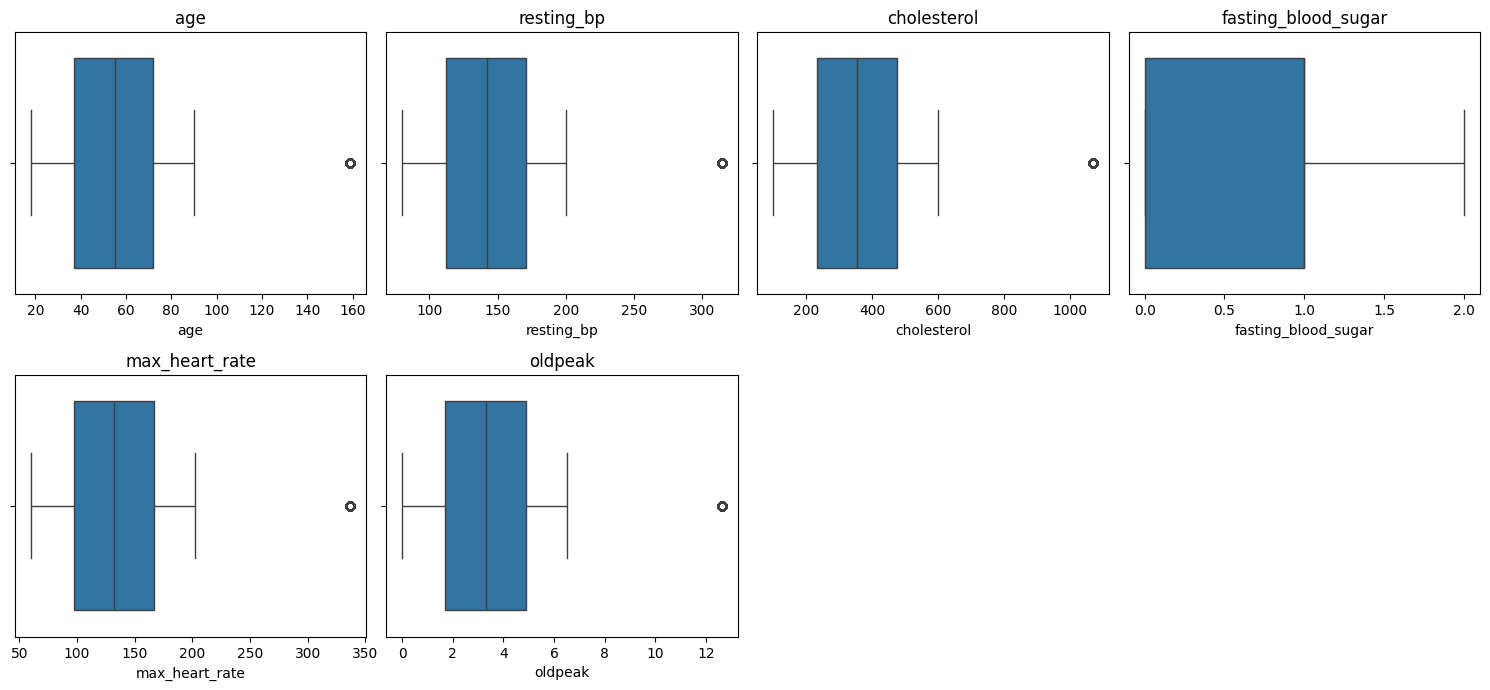

In [13]:
target = df['heart_disease']
features = df.drop(columns=['heart_disease'])
continuous_features = features.select_dtypes(include=['int64', 'float64']).columns


#identifying outliers using boxplots
plt.figure(figsize=(15, 10))

for i, col in enumerate(continuous_features):
    plt.subplot(3, 4, i+1)  
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

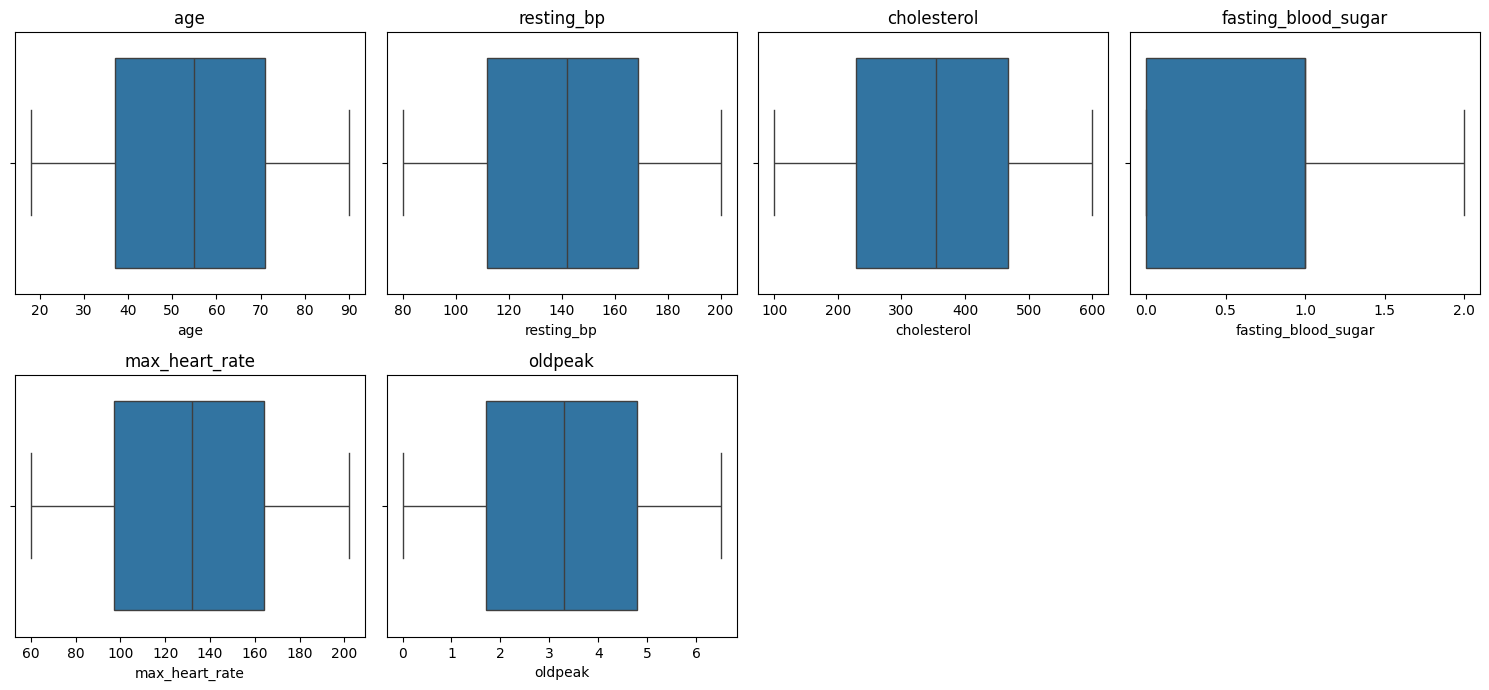

In [14]:
#removing outliers using iqr
for col in continuous_features:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

plt.figure(figsize=(15, 10))

for i, col in enumerate(continuous_features):
    plt.subplot(3, 4, i+1)  
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [15]:
#exporting the cleaned dataset to a new csv file
df.to_csv('heart_disease_prediction_cleaned.csv', index=False)

### ------Data cleaning complete-------

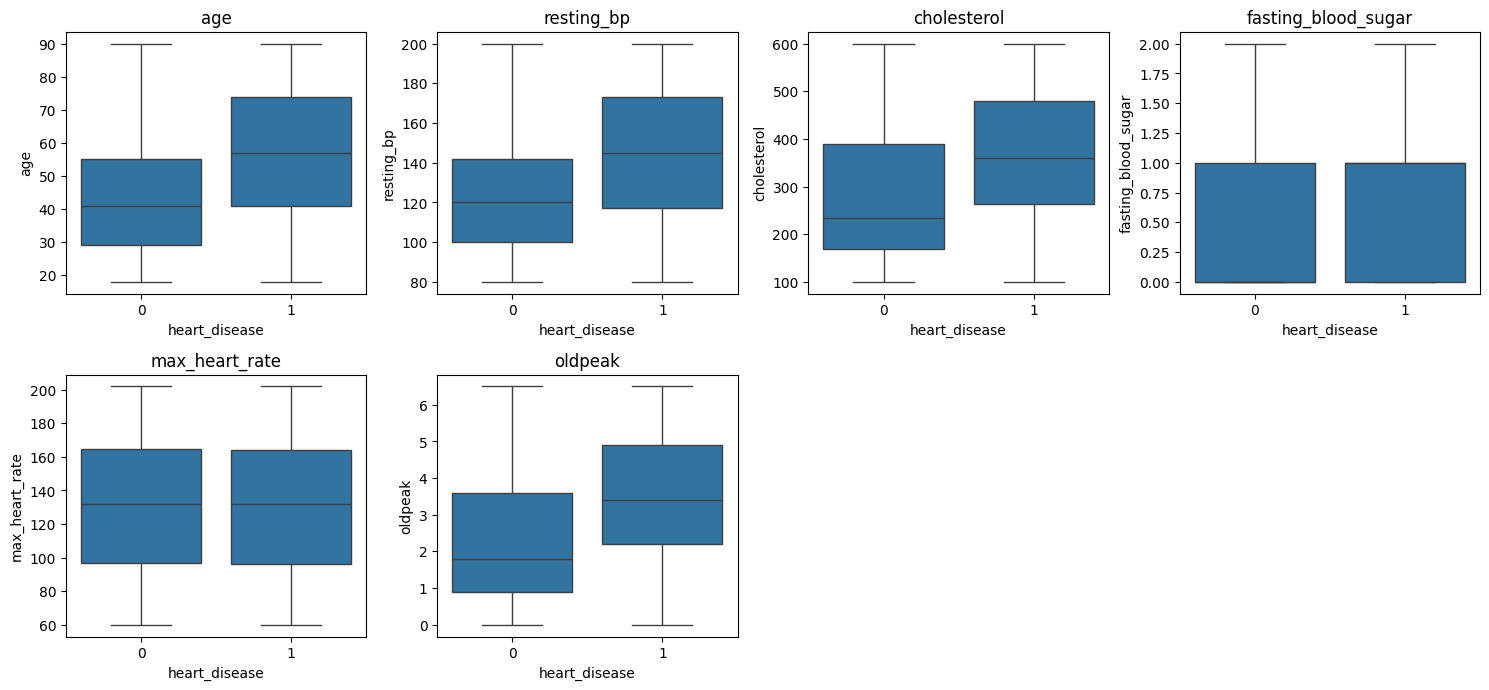

In [16]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(continuous_features):
    plt.subplot(3, 4, i+1)
    sns.boxplot(x=target, y=col, data=df)
    plt.title(col)
plt.tight_layout()    
plt.show()

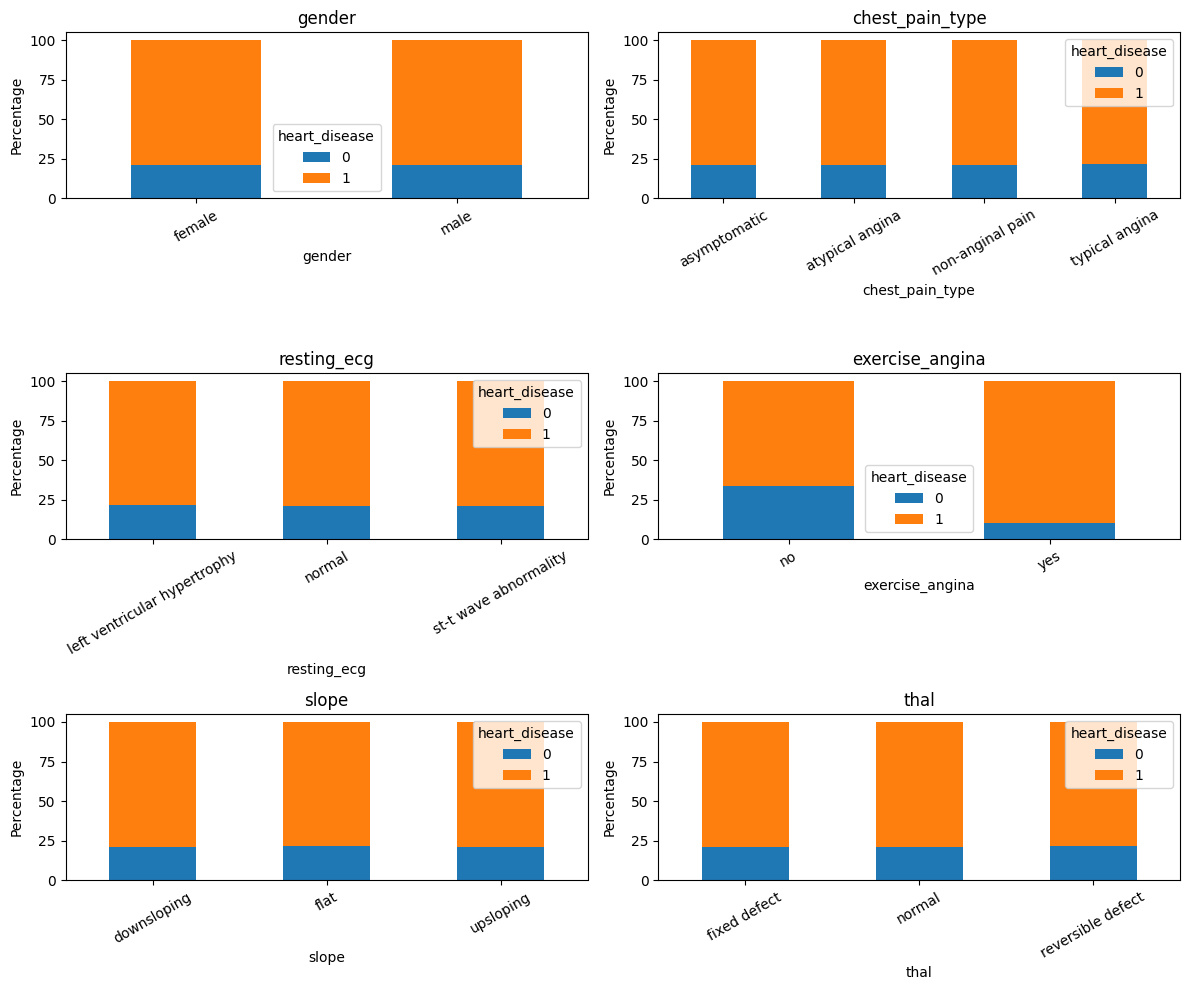

In [17]:
plt.figure(figsize=(12,10))
for i, col in enumerate(categorical_features, 1):
    plt.subplot(3, 2, i)
    
    ct = pd.crosstab(df[col], df['heart_disease'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=plt.gca())
    
    plt.title(col)
    plt.ylabel("Percentage")
    plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [18]:
#encoding categorical features

df['gender'] = df['gender'].map({'male': 1, 'female': 0})
df['exercise_angina'] = df['exercise_angina'].map({'yes': 1, 'no': 0})

df = pd.get_dummies(df, columns=['chest_pain_type', 'resting_ecg', 'thal'], drop_first=True)

mapping = {
    'upsloping': 0,
    'flat': 1,
    'downsloping': 2
}

df['slope'] = df['slope'].map(mapping)

df.sample(5)

,age,gender,resting_bp,cholesterol,fasting_blood_sugar,max_heart_rate,exercise_angina,oldpeak,slope,heart_disease,chest_pain_type_atypical angina,chest_pain_type_non-anginal pain,chest_pain_type_typical angina,resting_ecg_normal,resting_ecg_st-t wave abnormality,thal_normal,thal_reversible defect
3873,36,1,178,286,1,109,1,3.0,0,1,True,False,False,False,True,False,False
54067,38,1,154,271,0,71,0,6.4,0,1,False,False,True,False,False,False,False
24004,73,0,163,202,1,196,0,0.1,1,1,True,False,False,False,False,True,False
24354,53,0,177,517,0,93,1,1.7,1,1,False,False,True,False,False,False,True
4483,80,0,85,432,0,78,1,4.2,0,1,False,False,False,True,False,False,True


In [19]:
X = df.drop(columns=['heart_disease'])
y = df['heart_disease']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [20]:
scaler = StandardScaler()

X_train[continuous_features] = scaler.fit_transform(X_train[continuous_features])
X_test[continuous_features] = scaler.transform(X_test[continuous_features])

In [21]:
X_train

,age,gender,resting_bp,cholesterol,fasting_blood_sugar,max_heart_rate,exercise_angina,oldpeak,slope,chest_pain_type_atypical angina,chest_pain_type_non-anginal pain,chest_pain_type_typical angina,resting_ecg_normal,resting_ecg_st-t wave abnormality,thal_normal,thal_reversible defect
26527,1.066355,1,-0.423614,-0.182413,0.834092,0.035403,0,0.967092,0,False,True,False,False,True,False,True
49958,-0.150001,1,-1.772544,-1.144590,0.834092,-0.683917,0,-0.510514,0,False,False,True,False,False,False,False
36235,0.433850,0,-0.511587,-0.182413,0.834092,0.159424,0,1.733258,1,False,True,False,False,False,False,True
48855,1.455589,0,0.514773,0.166822,-1.035486,0.134620,1,-1.495584,0,False,False,False,True,False,True,False
20858,-0.052692,1,1.130589,-0.182413,-1.035486,0.481878,1,1.459628,2,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13365,-1.220394,1,0.309501,-0.467502,-1.035486,-1.204804,0,-1.331406,1,False,False,False,False,True,True,False
53292,0.920392,0,-1.772544,-0.545902,-1.035486,-0.708721,0,1.240723,0,False,True,False,False,False,False,False
45509,-1.463665,1,0.074904,1.093362,-1.035486,-1.676083,1,-0.346335,0,False,False,False,False,True,True,False
1006,-0.441926,0,1.541133,-1.272880,0.834092,-0.783133,0,-1.003049,1,True,False,False,False,True,False,False


# Logistic Regression

In [22]:
from sklearn.linear_model import LogisticRegression

In [23]:
features = list(X.columns)

best_features = features.copy()
best_score = 0

while len(best_features) > 1:
    
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train[best_features], y_train)
    
    y_pred = model.predict(X_test[best_features])
    score = accuracy_score(y_test, y_pred)
    
    print(f"\nFeatures: {best_features}")
    print(f"Accuracy: {score:.4f}")
    
    # Get coefficients
    coef = np.abs(model.coef_[0])
    
    # Find least important feature
    min_index = np.argmin(coef)
    removed_feature = best_features[min_index]
    
    print(f"Removing: {removed_feature}")
    
    # Try removing
    temp_features = best_features.copy()
    temp_features.remove(removed_feature)
    
    model.fit(X_train[temp_features], y_train)
    y_pred = model.predict(X_test[temp_features])
    new_score = accuracy_score(y_test, y_pred)
    
    # Keep removal only if performance not worse
    if new_score >= score:
        best_features = temp_features
        best_score = new_score
    else:
        break




Features: ['age', 'gender', 'resting_bp', 'cholesterol', 'fasting_blood_sugar', 'max_heart_rate', 'exercise_angina', 'oldpeak', 'slope', 'chest_pain_type_atypical angina', 'chest_pain_type_non-anginal pain', 'chest_pain_type_typical angina', 'resting_ecg_normal', 'resting_ecg_st-t wave abnormality', 'thal_normal', 'thal_reversible defect']
Accuracy: 0.8879
Removing: gender

Features: ['age', 'resting_bp', 'cholesterol', 'fasting_blood_sugar', 'max_heart_rate', 'exercise_angina', 'oldpeak', 'slope', 'chest_pain_type_atypical angina', 'chest_pain_type_non-anginal pain', 'chest_pain_type_typical angina', 'resting_ecg_normal', 'resting_ecg_st-t wave abnormality', 'thal_normal', 'thal_reversible defect']
Accuracy: 0.8879
Removing: chest_pain_type_non-anginal pain


In [24]:
print("\nFinal Features:", best_features)

final_model = LogisticRegression(max_iter=1000)
final_model.fit(X_train[best_features], y_train)

y_pred = final_model.predict(X_test[best_features])

print("\nFinal Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Final Features: ['age', 'resting_bp', 'cholesterol', 'fasting_blood_sugar', 'max_heart_rate', 'exercise_angina', 'oldpeak', 'slope', 'chest_pain_type_atypical angina', 'chest_pain_type_non-anginal pain', 'chest_pain_type_typical angina', 'resting_ecg_normal', 'resting_ecg_st-t wave abnormality', 'thal_normal', 'thal_reversible defect']

Final Accuracy: 0.8879396984924623

Confusion Matrix:
 [[1416  690]
 [ 425 7419]]


# KNN 

In [25]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, classification_report

# KNN Model
print("="*60)
print("K-NEAREST NEIGHBORS (KNN) CLASSIFIER")
print("="*60)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train[best_features], y_train)
y_pred_knn = knn.predict(X_test[best_features])

print("\n--- KNN Model Scores ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_knn):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_knn):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_knn):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_knn):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

K-NEAREST NEIGHBORS (KNN) CLASSIFIER

--- KNN Model Scores ---
Accuracy: 0.9068
Precision: 0.9223
Recall: 0.9629
F1-Score: 0.9422
ROC-AUC: 0.8305

Confusion Matrix:
[[1470  636]
 [ 291 7553]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.70      0.76      2106
           1       0.92      0.96      0.94      7844

    accuracy                           0.91      9950
   macro avg       0.88      0.83      0.85      9950
weighted avg       0.90      0.91      0.90      9950



In [26]:
from sklearn.svm import SVC

# SVM Model
print("\n" + "="*60)
print("SUPPORT VECTOR MACHINE (SVM) CLASSIFIER")
print("="*60)

svm = SVC(kernel='rbf', probability=True)
svm.fit(X_train[best_features], y_train)
y_pred_svm = svm.predict(X_test[best_features])

print("\n--- SVM Model Scores ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_svm):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_svm):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_svm):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, svm.predict_proba(X_test[best_features])[:, 1]):.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

# Comparison Summary
print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)
print(f"\n{'Metric':<15} {'Logistic Reg':<15} {'KNN':<15} {'SVM':<15}")
print("-"*60)
print(f"{'Accuracy':<15} {accuracy_score(y_test, y_pred):<15.4f} {accuracy_score(y_test, y_pred_knn):<15.4f} {accuracy_score(y_test, y_pred_svm):<15.4f}")
print(f"{'Precision':<15} {precision_score(y_test, y_pred):<15.4f} {precision_score(y_test, y_pred_knn):<15.4f} {precision_score(y_test, y_pred_svm):<15.4f}")
print(f"{'Recall':<15} {recall_score(y_test, y_pred):<15.4f} {recall_score(y_test, y_pred_knn):<15.4f} {recall_score(y_test, y_pred_svm):<15.4f}")
print(f"{'F1-Score':<15} {f1_score(y_test, y_pred):<15.4f} {f1_score(y_test, y_pred_knn):<15.4f} {f1_score(y_test, y_pred_svm):<15.4f}")


SUPPORT VECTOR MACHINE (SVM) CLASSIFIER

--- SVM Model Scores ---
Accuracy: 0.9228
Precision: 0.9367
Recall: 0.9675
F1-Score: 0.9518
ROC-AUC: 0.9600

Confusion Matrix:
[[1593  513]
 [ 255 7589]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.76      0.81      2106
           1       0.94      0.97      0.95      7844

    accuracy                           0.92      9950
   macro avg       0.90      0.86      0.88      9950
weighted avg       0.92      0.92      0.92      9950


MODEL COMPARISON SUMMARY

Metric          Logistic Reg    KNN             SVM            
------------------------------------------------------------
Accuracy        0.8879          0.9068          0.9228         
Precision       0.9149          0.9223          0.9367         
Recall          0.9458          0.9629          0.9675         
F1-Score        0.9301          0.9422          0.9518         
